In [16]:
import cv2
import kornia as K
import kornia.feature as KF
import matplotlib.pyplot as plt
import numpy as np
import torch
from kornia_moons.viz import draw_LAF_matches
from PIL import Image
import certifi
import ssl 

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

In [17]:
loftr = KF.LoFTR(pretrained='outdoor')
loftr = loftr.eval()

## Setup images

In [18]:
fname1 = "sample_images/image1.jpg"
fname2 = "sample_images/image1.jpg"
# --- Load images (grayscale, float32, normalized) ---
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (1500, 1000))  # optional but recommended
    img = torch.from_numpy(img).float() / 255.0
    return img.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

img1 = load_image(fname1)
img2 = load_image(fname2)


In [19]:
# --- Run LoFTR ---
with torch.no_grad():
    out = loftr({"image0": img1, "image1": img2})

mkpts0 = out["keypoints0"].cpu().numpy()
mkpts1 = out["keypoints1"].cpu().numpy()
conf = out["confidence"].cpu().numpy()

# --- Filter matches (important) ---
mask = conf > 0.5
mkpts0 = mkpts0[mask]
mkpts1 = mkpts1[mask]

print(f"# matches after filtering: {len(mkpts0)}")

# matches after filtering: 20036


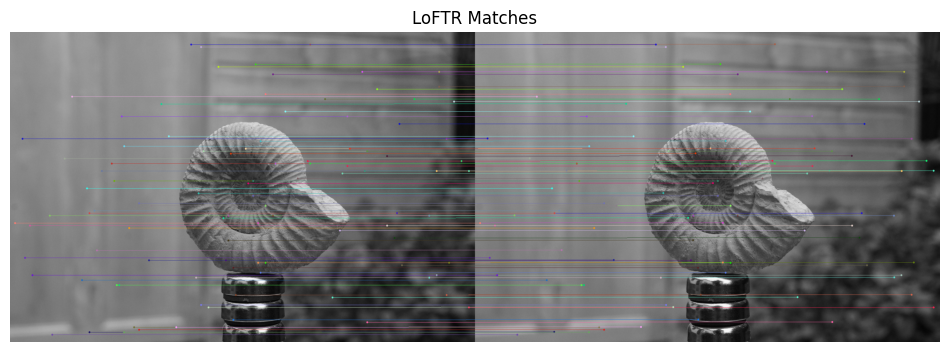

In [20]:
# --- Visualization ---
def draw_matches(img1, img2, pts1, pts2, max_draw=100):
    # Convert to RGB for plotting
    img1 = img1.squeeze().numpy()
    img2 = img2.squeeze().numpy()

    img1 = (img1 * 255).astype(np.uint8)
    img2 = (img2 * 255).astype(np.uint8)

    img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)

    # Stack images side by side
    h1, w1, _ = img1.shape
    h2, w2, _ = img2.shape

    H = max(h1, h2)
    canvas = np.zeros((H, w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1
    canvas[:h2, w1:w1+w2] = img2

    # Draw matches
    idxs = np.random.choice(len(pts1), min(max_draw, len(pts1)), replace=False)

    for i in idxs:
        x1, y1 = pts1[i]
        x2, y2 = pts2[i]

        color = tuple(np.random.randint(0, 255, 3).tolist())

        pt1 = (int(x1), int(y1))
        pt2 = (int(x2 + w1), int(y2))

        cv2.circle(canvas, pt1, 3, color, -1)
        cv2.circle(canvas, pt2, 3, color, -1)
        cv2.line(canvas, pt1, pt2, color, 1)

    return canvas

vis = draw_matches(img1, img2, mkpts0, mkpts1)

# --- Show result ---
plt.figure(figsize=(12,6))
plt.imshow(vis)
plt.axis('off')
plt.title("LoFTR Matches")
plt.show()